In [25]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
os.makedirs('plots', exist_ok=True)

In [26]:
DATA_DIR = 'data' if os.path.exists('data/games.csv') else '../data-ba576project'

games = pd.read_csv(f'{DATA_DIR}/games.csv')
ranking = pd.read_csv(f'{DATA_DIR}/ranking.csv')

In [27]:
games['GAME_DATE_EST'] = pd.to_datetime(games['GAME_DATE_EST'])
games_clean = games.dropna(subset=['PTS_home', 'PTS_away', 'HOME_TEAM_WINS']).copy()
games_clean['HOME_TEAM_WINS'] = games_clean['HOME_TEAM_WINS'].astype(int)

ranking['STANDINGSDATE'] = pd.to_datetime(ranking['STANDINGSDATE'])
ranking[['HOME_W', 'HOME_L']] = ranking['HOME_RECORD'].str.split('-', expand=True).astype(float)
ranking[['ROAD_W', 'ROAD_L']] = ranking['ROAD_RECORD'].str.split('-', expand=True).astype(float)

In [28]:
ranking_cols = [
    'TEAM_ID', 'STANDINGSDATE', 'CONFERENCE', 'G', 'W', 'L', 'W_PCT',
    'HOME_W', 'HOME_L', 'ROAD_W', 'ROAD_L'
]

rank_slim = ranking[ranking_cols].copy()
games_sorted = games_clean.sort_values('GAME_DATE_EST').copy()
rank_sorted = rank_slim.sort_values('STANDINGSDATE').copy()

home_rank = pd.merge_asof(
    games_sorted[['GAME_ID', 'GAME_DATE_EST', 'HOME_TEAM_ID']].rename(columns={'HOME_TEAM_ID': 'TEAM_ID'}),
    rank_sorted,
    left_on='GAME_DATE_EST',
    right_on='STANDINGSDATE',
    by='TEAM_ID',
    direction='backward'
)

home_rank = home_rank.rename(columns={
    'CONFERENCE': 'HOME_CONF',
    'G': 'HOME_G',
    'W': 'HOME_W_season',
    'L': 'HOME_L_season',
    'W_PCT': 'HOME_W_PCT',
    'HOME_W': 'HOME_HOME_W',
    'HOME_L': 'HOME_HOME_L',
    'ROAD_W': 'HOME_ROAD_W',
    'ROAD_L': 'HOME_ROAD_L'
}).drop(columns=['STANDINGSDATE', 'TEAM_ID'])

away_rank = pd.merge_asof(
    games_sorted[['GAME_ID', 'GAME_DATE_EST', 'VISITOR_TEAM_ID']].rename(columns={'VISITOR_TEAM_ID': 'TEAM_ID'}),
    rank_sorted,
    left_on='GAME_DATE_EST',
    right_on='STANDINGSDATE',
    by='TEAM_ID',
    direction='backward'
)

away_rank = away_rank.rename(columns={
    'CONFERENCE': 'AWAY_CONF',
    'G': 'AWAY_G',
    'W': 'AWAY_W_season',
    'L': 'AWAY_L_season',
    'W_PCT': 'AWAY_W_PCT',
    'HOME_W': 'AWAY_HOME_W',
    'HOME_L': 'AWAY_HOME_L',
    'ROAD_W': 'AWAY_ROAD_W',
    'ROAD_L': 'AWAY_ROAD_L'
}).drop(columns=['STANDINGSDATE', 'TEAM_ID'])

In [29]:
stat_cols = ['PTS', 'FG_PCT', 'FT_PCT', 'FG3_PCT', 'AST', 'REB']

home_games = games_sorted[['GAME_ID', 'GAME_DATE_EST', 'HOME_TEAM_ID', 'SEASON'] +
                          [c + '_home' for c in stat_cols]].copy()
home_games.columns = ['GAME_ID', 'GAME_DATE_EST', 'TEAM_ID', 'SEASON'] + stat_cols

away_games = games_sorted[['GAME_ID', 'GAME_DATE_EST', 'VISITOR_TEAM_ID', 'SEASON'] +
                          [c + '_away' for c in stat_cols]].copy()
away_games.columns = ['GAME_ID', 'GAME_DATE_EST', 'TEAM_ID', 'SEASON'] + stat_cols

all_team_games = pd.concat([home_games, away_games]).sort_values(['TEAM_ID', 'GAME_DATE_EST'])

WINDOW = 10
rolling = (
    all_team_games.groupby('TEAM_ID')[stat_cols]
    .apply(lambda x: x.shift(1).rolling(WINDOW, min_periods=3).mean())
)
rolling.columns = [f'ROLL_{c}' for c in stat_cols]

all_team_games = pd.concat(
    [all_team_games.reset_index(drop=True), rolling.reset_index(drop=True)],
    axis=1
)

roll_cols = [f'ROLL_{c}' for c in stat_cols]

home_rolling = all_team_games.loc[
    all_team_games['GAME_ID'].isin(home_games['GAME_ID'])
].groupby('GAME_ID').first()[roll_cols].rename(columns={c: f'HOME_{c}' for c in roll_cols})

away_rolling = all_team_games.loc[
    all_team_games['GAME_ID'].isin(away_games['GAME_ID'])
].groupby('GAME_ID').last()[roll_cols].rename(columns={c: f'AWAY_{c}' for c in roll_cols})

In [30]:
df = games_sorted[['GAME_ID', 'GAME_DATE_EST', 'SEASON', 'HOME_TEAM_ID',
                   'VISITOR_TEAM_ID', 'HOME_TEAM_WINS']].copy()

df = df.merge(home_rank, on=['GAME_ID', 'GAME_DATE_EST'], how='left')
df = df.merge(away_rank, on=['GAME_ID', 'GAME_DATE_EST'], how='left')
df = df.merge(home_rolling, on='GAME_ID', how='left')
df = df.merge(away_rolling, on='GAME_ID', how='left')

df['W_PCT_DIFF'] = df['HOME_W_PCT'] - df['AWAY_W_PCT']
df['HOME_HOME_W_PCT'] = df['HOME_HOME_W'] / (df['HOME_HOME_W'] + df['HOME_HOME_L'])
df['AWAY_ROAD_W_PCT'] = df['AWAY_ROAD_W'] / (df['AWAY_ROAD_W'] + df['AWAY_ROAD_L'])
df['HOME_VS_AWAY_ROAD'] = df['HOME_HOME_W_PCT'] - df['AWAY_ROAD_W_PCT']
df['SAME_CONFERENCE'] = (df['HOME_CONF'] == df['AWAY_CONF']).astype(int)
df['MONTH'] = df['GAME_DATE_EST'].dt.month
df['DAY_OF_WEEK'] = df['GAME_DATE_EST'].dt.dayofweek

for s in stat_cols:
    df[f'ROLL_{s}_DIFF'] = df[f'HOME_ROLL_{s}'] - df[f'AWAY_ROLL_{s}']

In [31]:
feature_cols = [
    'HOME_W_PCT', 'AWAY_W_PCT', 'W_PCT_DIFF',
    'HOME_HOME_W_PCT', 'AWAY_ROAD_W_PCT', 'HOME_VS_AWAY_ROAD',
    'HOME_G', 'AWAY_G',
    'SAME_CONFERENCE', 'MONTH', 'DAY_OF_WEEK',
    'HOME_ROLL_PTS', 'HOME_ROLL_FG_PCT', 'HOME_ROLL_FT_PCT',
    'HOME_ROLL_FG3_PCT', 'HOME_ROLL_AST', 'HOME_ROLL_REB',
    'AWAY_ROLL_PTS', 'AWAY_ROLL_FG_PCT', 'AWAY_ROLL_FT_PCT',
    'AWAY_ROLL_FG3_PCT', 'AWAY_ROLL_AST', 'AWAY_ROLL_REB',
    'ROLL_PTS_DIFF', 'ROLL_FG_PCT_DIFF', 'ROLL_FT_PCT_DIFF',
    'ROLL_FG3_PCT_DIFF', 'ROLL_AST_DIFF', 'ROLL_REB_DIFF',
]

target = 'HOME_TEAM_WINS'

model_df = df.dropna(subset=feature_cols + [target]).copy()

print(model_df.shape)
print(model_df[['SEASON', 'HOME_TEAM_WINS']].head())

#-----------------------------
# This check is useful because it tells us:
# model_df exists; it has the expected number of rows SEASON and HOME_TEAM_WINS are present; 
# the target is coded as 0/1 like expected
#-----------------------------

# this shows what seasons are included (for a check)
print(model_df['SEASON'].min())
print(model_df['SEASON'].max())

(26639, 49)
    SEASON  HOME_TEAM_WINS
23    2003               0
30    2003               0
32    2003               1
34    2003               0
40    2003               1
2003
2022


In [32]:
# -------------------------------
# COVID Analysis
# -------------------------------
covid_seasons = [2020, 2021]

model_df['COVID_ERA'] = model_df['SEASON'].isin(covid_seasons).astype(int)

covid_summary = model_df.groupby('COVID_ERA')['HOME_TEAM_WINS'].agg(['mean', 'count'])

print("\nCOVID Analysis:")
print(covid_summary)


COVID Analysis:
               mean  count
COVID_ERA                 
0          0.593235  23827
1          0.551565   2812


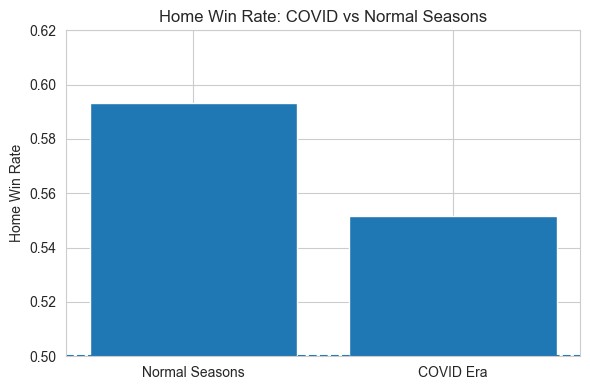

In [33]:
# -------------------------------
# COVID Analysis Visualization
# -------------------------------

import matplotlib.pyplot as plt

labels = ['Normal Seasons', 'COVID Era']
values = covid_summary['mean'].values

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.axhline(y=0.5, linestyle='--')
plt.title('Home Win Rate: COVID vs Normal Seasons')
plt.ylabel('Home Win Rate')
plt.ylim(0.5, 0.62)  # zoom in to show difference clearly
plt.tight_layout()
plt.savefig('plots/covid_analysis.png')
plt.show()

Since, naturally, there are significantly more regular season games than COVID games, we can include a confidence interval and weighted analysis.

In [34]:
import numpy as np

# extract values
p = covid_summary['mean']
n = covid_summary['count']

# standard error
se = np.sqrt(p * (1 - p) / n)

# 95% confidence interval
covid_summary['ci_lower'] = p - 1.96 * se
covid_summary['ci_upper'] = p + 1.96 * se

print(covid_summary)

               mean  count  ci_lower  ci_upper
COVID_ERA                                     
0          0.593235  23827  0.586997  0.599472
1          0.551565   2812  0.533183  0.569947


✅ 2. WEIGHTED ANALYSIS (BE CAREFUL HERE)
⚠️ Important:

You already used all games, so your mean is already naturally weighted.

So don’t fake this.

🧠 What you can legitimately do

Instead, frame it like this:

Option A (best for your case):

Compare season-level averages instead of game-level

In [35]:
# -------------------------------
# COVID Analysis Weighted
# -------------------------------

# average win rate per season
season_avg = model_df.groupby('SEASON')['HOME_TEAM_WINS'].mean().reset_index()

# label COVID
season_avg['COVID_ERA_WEIGHTED'] = season_avg['SEASON'].isin([2020, 2021]).astype(int)

# average across seasons (not games)
weighted_summary = season_avg.groupby('COVID_ERA_WEIGHTED')['HOME_TEAM_WINS'].mean()

print(weighted_summary)

COVID_ERA_WEIGHTED
0    0.592865
1    0.551581
Name: HOME_TEAM_WINS, dtype: float64
